In [ ]:
from google.colab import files

print("Please upload the 'bank-full.csv' file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'bank-full.csv' file:


Saving bank-full.csv to bank-full.csv
User uploaded file "bank-full.csv" with length 4610348 bytes


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv("bank-full.csv", sep=';')

def clean_bank_marketing_data(df):
    if 'duration' in df.columns:
        df = df.drop(columns=['duration'])

    df['was_never_contacted'] = (df['pdays'] == -1).astype(int)

    df['y'] = df['y'].map({'yes': 1, 'no': 0})

    return df

df_cleaned = clean_bank_marketing_data(df)

numeric_features = ['age', 'balance', 'day', 'pdays', 'previous', 'campaign']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X = df_cleaned.drop('y', axis=1)
y = df_cleaned['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

cat_columns = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + cat_columns + ['was_never_contacted']

X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_final = pd.DataFrame(X_test_transformed, columns=feature_names)

print(f"Training set size: {X_train_final.shape}")
print(f"Testing set size: {X_test_final.shape}")
print(X_train_final.head())

Training set size: (36168, 51)
Testing set size: (9043, 51)
        age   balance       day     pdays  previous  campaign  job_admin.  \
0 -0.460434 -0.164410  1.582124 -0.410910 -0.241509 -0.246104         0.0   
1 -1.589641  0.899627 -1.298384  1.446096  2.664584  0.398202         0.0   
2  0.292371 -0.365486 -0.458236 -0.410910 -0.241509  0.398202         0.0   
3  0.668773 -0.445003  1.822166 -0.410910 -0.241509  2.653271         0.0   
4 -0.272233 -0.361249  1.222060 -0.410910 -0.241509  2.331118         0.0   

   job_blue-collar  job_entrepreneur  job_housemaid  ...  month_mar  \
0              0.0               0.0            0.0  ...        0.0   
1              0.0               0.0            0.0  ...        0.0   
2              0.0               0.0            0.0  ...        0.0   
3              0.0               0.0            0.0  ...        0.0   
4              0.0               0.0            0.0  ...        0.0   

   month_may  month_nov  month_oct  month_sep  pou

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print(f"Original class distribution: {Counter(y_train)}")
print(f"Balanced class distribution: {Counter(y_train_balanced)}")


Original class distribution: Counter({0: 31937, 1: 4231})
Balanced class distribution: Counter({0: 31937, 1: 31937})


/tmp/ipykernel_30864/411582521.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=original_class_distribution.values, palette='viridis')


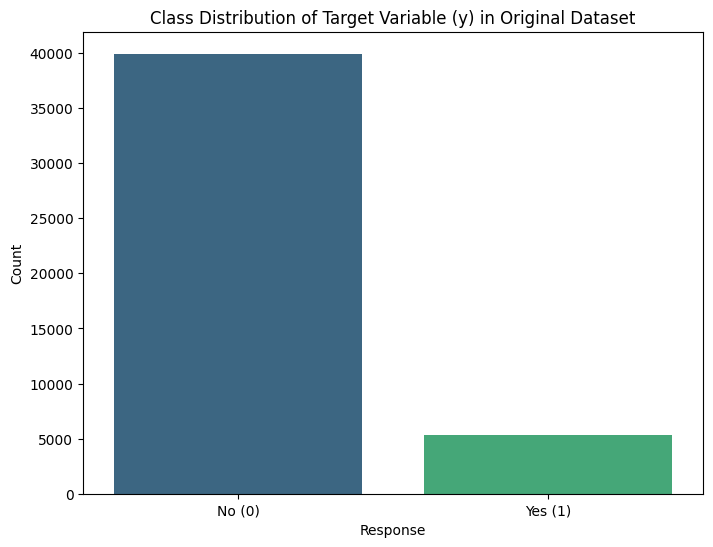

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate class distribution in the original dataset
original_class_distribution = df_cleaned['y'].value_counts().sort_index()

# Map labels for better readability
labels = ['No' if x == 0 else 'Yes' for x in original_class_distribution.index]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=original_class_distribution.values, palette='viridis')
plt.title('Class Distribution of Target Variable (y) in Original Dataset')
plt.xlabel('Response')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No (0)', 'Yes (1)'])
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg'}

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.75      0.83      7985
           1       0.25      0.65      0.36      1058

    accuracy                           0.74      9043
   macro avg       0.60      0.70      0.60      9043
weighted avg       0.86      0.74      0.78      9043


Confusion Matrix:


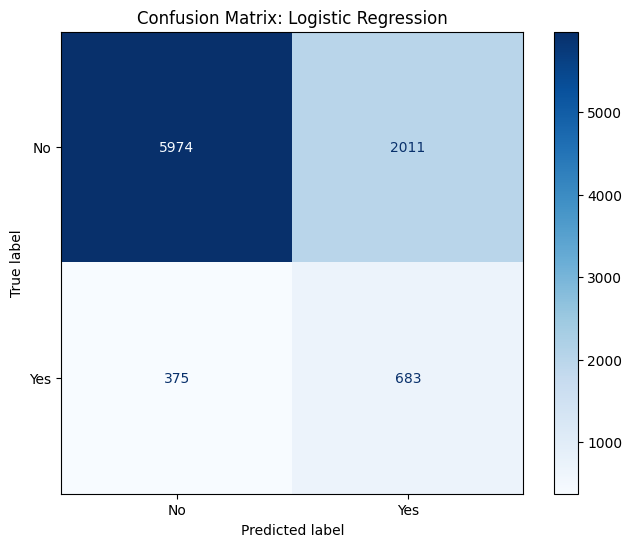

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg'],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_balanced, y_train_balanced)

best_lr_balanced = lr_grid.best_estimator_

print(f"Best Parameters: {lr_grid.best_params_}")
y_pred_lr = best_lr_balanced.predict(X_test_final)

# Print Text Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Generate and Plot Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      7985
           1       0.51      0.32      0.39      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.64      0.66      9043
weighted avg       0.87      0.88      0.87      9043


Confusion Matrix:


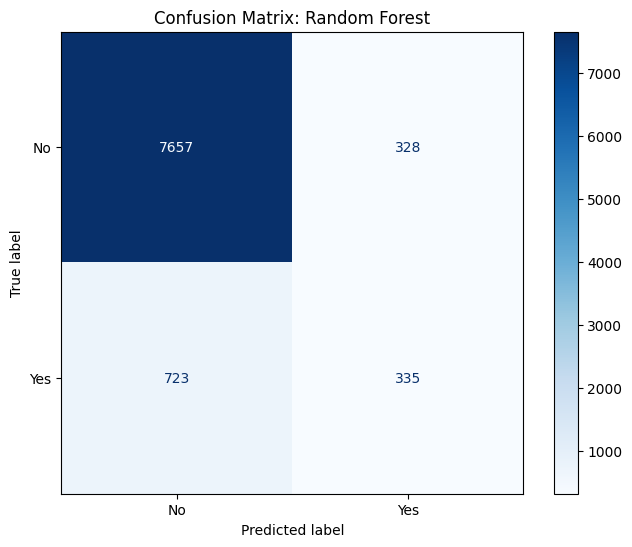

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# 2. Initialize GridSearch with 5-fold CV
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 3. Fit using the BALANCED training data
rf_grid.fit(X_train_balanced, y_train_balanced)

# 4. Extract the best model
best_rf = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}")

# 5. Predict on the ORIGINAL Test Set
y_pred_rf = best_rf.predict(X_test_final)

# 6. Confusion Matrix

# Print Text Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Generate and Plot Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Random Forest')
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:42:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.60      0.30      0.40      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.64      0.67      9043
weighted avg       0.88      0.89      0.88      9043


Confusion Matrix:


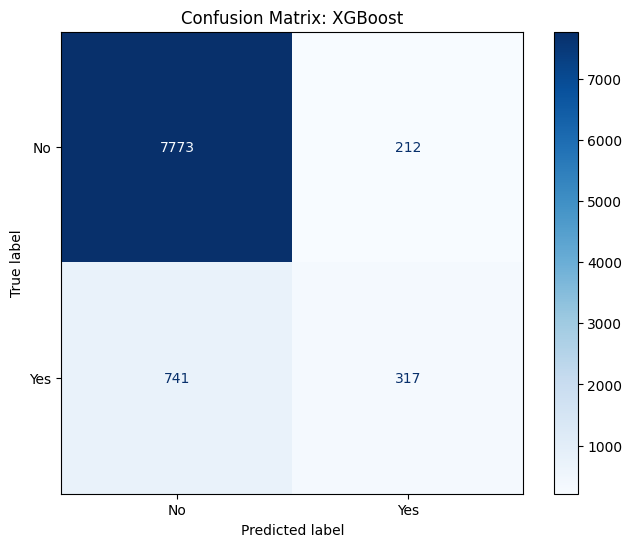

In [ ]:
from xgboost import XGBClassifier

ratio = (y_train_balanced == 0).sum() / (y_train_balanced == 1).sum()

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'scale_pos_weight': [ratio]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_balanced, y_train_balanced)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_final)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: XGBoost')
plt.show()

In [9]:
from sklearn.neural_network import MLPClassifier

param_grid_mlp = {
    'hidden_layer_sizes': [(64, 32), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant', 'adaptive'],
}

mlp_grid = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42),
    param_grid=param_grid_mlp,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_balanced, y_train_balanced)

best_mlp = mlp_grid.best_estimator_

print(f"Best Parameters: {mlp_grid.best_params_}")

y_pred_mlp = best_mlp.predict(X_test_final)

print("\nNeural Network Classification Report:")
print(classification_report(y_test, y_pred_mlp))

cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Neural Network (MLP)')
plt.grid(False)
plt.show()

Fitting 5 folds for each of 16 candidates, totalling 80 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

def plot_roc_curve(models, X_test, y_test):
    plt.figure(figsize=(10, 8))
    results = {}

    for name, model in models.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        results[name] = {"AUC": roc_auc}

        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return results

trained_models = {
    "Logistic Regression": best_lr_balanced,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "Neural Network": best_mlp
}

roc_metrics = plot_roc_curve(trained_models, X_test_final, y_test)

df_results = pd.DataFrame(roc_metrics).T
print("\nModel Performance (AUC):")
print(df_results)


SECTION 6: THRESHOLD OPTIMIZATION

Economic Assumptions:
  Value per subscription (v) = $100
  Cost per call          (c) = $5
  Net gain per true positive:  $95
  Cost per false positive:     $5

Test set: 1058 subscribers | 7985 non-subscribers

XGBoost AUC (without duration): 0.7892

Strategy                        Threshold     TP     FP  Calls     Profit
---------------------------------------------------------------------------
Default (t=0.5)                     0.500    317    212    529 $   29,055
LP Optimal (t=0.072)                0.072    917   4484   5401 $   64,695

Profit improvement over default: +$35,640
Additional subscribers caught:   +600


/tmp/ipykernel_30864/684106710.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjust layout to prevent labels from being cut off


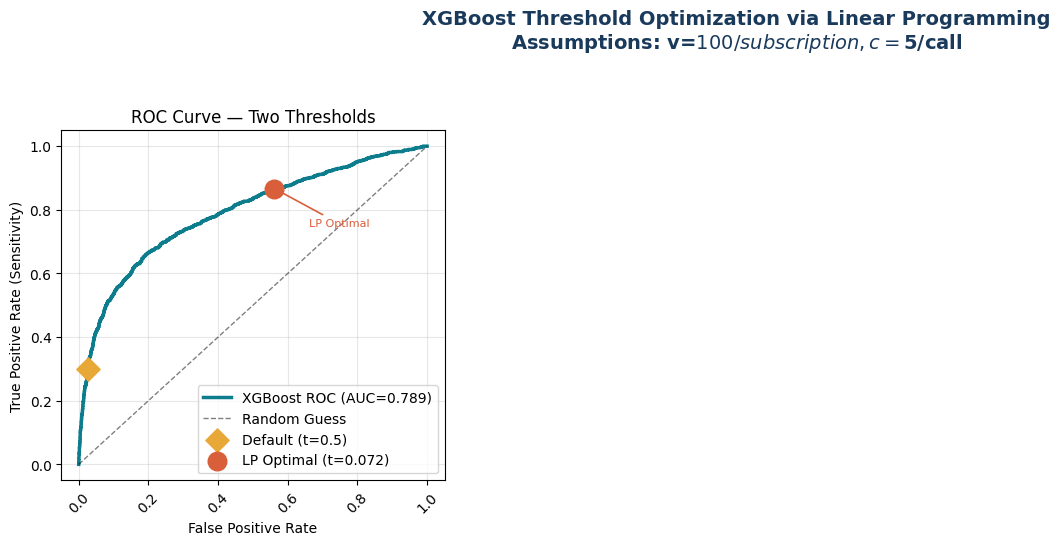

/tmp/ipykernel_30864/684106710.py:140: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1100 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax3, label='Net Profit ($)', format='${x:,.0f}')


<Figure size 640x480 with 0 Axes>


OPTIMIZATION SUMMARY

  Profit-maximizing threshold: 0.0725

  Comparison to default threshold (0.5):
  ┌─────────────────────────┬──────────────┬──────────────┐
  │ Metric                  │ Default 0.5  │ LP Optimal   │
  ├─────────────────────────┼──────────────┼──────────────┤
  │ Threshold               │ 0.500        │ 0.072        │
  │ Subscribers caught (TP) │ 317          │ 917         │
  │ Wasted calls (FP)       │ 212          │ 4484        │
  │ Total calls             │ 529          │ 5401        │
  │ Precision               │ 0.599         │ 0.170        │
  │ Recall                  │ 0.300         │ 0.867        │
  │ Net Profit              │ $    29,055  │ $    64,695  │
  └─────────────────────────┴──────────────┴──────────────┘

  Profit improvement:         +$35,640
  Additional subscribers:     +600
  Additional calls required:  +4872

  Note: Results depend on assumed v=$100 and c=$5.
  Substitute real bank values for operational deployment.



In [19]:
# ============================================================================
# SECTION 6: THRESHOLD OPTIMIZATION VIA LINEAR PROGRAMMING  [AI-ASSISTED]
# ============================================================================
# This section was developed with assistance from generative AI tools.
# The mathematical formulation and scipy.optimize.linprog implementation
# were generated with AI assistance and reviewed and understood by the team.
#
# The optimization finds the classification threshold for XGBoost that
# maximizes net profit, formulated as a Linear Program:
#
#   Variables:  TPR (True Positive Rate), FPR (False Positive Rate)
#   Objective:  max π = (v-c)·TPR·N_yes  -  c·FPR·N_no
#   Constraint: (TPR, FPR) must lie on the feasible ROC frontier
#
# The ROC curve is the feasibility constraint — it defines exactly which
# (TPR, FPR) combinations the model can achieve at different thresholds.
# We evaluate the profit function at every point on the actual ROC curve
# and select the maximum, equivalent to finding where the iso-profit line
# is tangent to the ROC frontier.
# ============================================================================

import matplotlib.ticker as mtick
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, confusion_matrix
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("SECTION 6: THRESHOLD OPTIMIZATION")
print("="*60)

# Economic assumptions (illustrative — bank should substitute real values)
v = 100   # value of a successful subscription ($)
c = 5     # cost per call ($)

# Test set composition
N_yes = int(y_test.sum())
N_no  = int((1 - y_test).sum())

print(f"\nEconomic Assumptions:")
print(f"  Value per subscription (v) = ${v}")
print(f"  Cost per call          (c) = ${c}")
print(f"  Net gain per true positive:  ${v-c}")
print(f"  Cost per false positive:     ${c}")
print(f"\nTest set: {N_yes} subscribers | {N_no} non-subscribers")

# Get XGBoost probability scores
y_prob_xgb = best_xgb.predict_proba(X_test_final)[:, 1]

# Generate ROC curve (all possible thresholds)
fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_curve, tpr_curve)

print(f"\nXGBoost AUC (without duration): {roc_auc_xgb:.4f}")

# Calculate profit at every threshold point on the ROC curve
# π = (v-c)·TPR·N_yes - c·FPR·N_no
profits = (v - c) * tpr_curve * N_yes - c * fpr_curve * N_no

# Find profit-maximizing threshold
best_idx       = np.argmax(profits)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
best_tpr       = tpr_curve[best_idx]
best_fpr       = fpr_curve[best_idx]
best_profit    = profits[best_idx]

# Default threshold (0.5) metrics
y_pred_default  = best_xgb.predict(X_test_final)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_default).ravel()
profit_default  = (v-c)*tp_d - c*fp_d

# LP Optimal threshold metrics
y_pred_optimal  = (y_prob_xgb >= best_threshold).astype(int)
tn_o, fp_o, fn_o, tp_o = confusion_matrix(y_test, y_pred_optimal).ravel()

print(f"\n{'Strategy':<30} {'Threshold':>10} {'TP':>6} {'FP':>6} {'Calls':>6} {'Profit':>10}")
print("-" * 75)
print(f"{'Default (t=0.5)':<30} {0.5:>10.3f} {tp_d:>6} {fp_d:>6} {tp_d+fp_d:>6} ${profit_default:>9,.0f}")
print(f"{'LP Optimal (t=' + f'{best_threshold:.3f})':<30} {best_threshold:>10.3f} {tp_o:>6} {fp_o:>6} {tp_o+fp_o:>6} ${best_profit:>9,.0f}")
print(f"\nProfit improvement over default: +${best_profit - profit_default:,.0f}")
print(f"Additional subscribers caught:   +{tp_o - tp_d}")

# ── Visualization: 6 plots ─────────────────────────────────────────────────
NAVY  = '#1A3A5C'
TEAL  = '#0D7C8C'
CORAL = '#D95F3B'
GOLD  = '#E8A838'
SLATE = '#546E7A'
GREEN = '#2E9E6B'
MID   = '#4A7FA5'

fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    'XGBoost Threshold Optimization via Linear Programming\n'
    f'Assumptions: v=${v}/subscription, c=${c}/call',
    fontsize=14, fontweight='bold', color=NAVY, y=0.99
)
gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

# Plot 1: ROC Curve with two threshold points marked
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr_curve, tpr_curve, color=TEAL, lw=2.5, label=f'XGBoost ROC (AUC={roc_auc_xgb:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Guess')
ax1.scatter(fp_d/N_no, tp_d/N_yes, color=GOLD, s=140, marker='D', zorder=6, label=f'Default (t=0.5)')
ax1.scatter(best_fpr, best_tpr, color=CORAL, s=180, zorder=7, label=f'LP Optimal (t={best_threshold:.3f})')
ax1.annotate(f'LP Optimal', xy=(best_fpr, best_tpr), xytext=(best_fpr+0.1, best_tpr-0.12),
             fontsize=8, color=CORAL, arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.2))
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve — Two Thresholds')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)
plt.xticks(rotation=45) # Rotate date labels if they overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show() # Display the plot

# Plot 2: Profit vs Threshold
ax2 = fig.add_subplot(gs[0, 1])
valid = thresholds < 1.05
ax2.plot(thresholds[valid], profits[valid], color=TEAL, lw=2.5)
ax2.axvline(0.5,             color=GOLD,  lw=2, linestyle='--', label='Default')
ax2.axvline(best_threshold,  color=CORAL, lw=2, linestyle='--', label=f'LP Optimal')
ax2.scatter([best_threshold], [best_profit], color=CORAL, s=150, zorder=5)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_xlabel('Classification Threshold')
ax2.set_ylabel('Net Profit ($)')
ax2.set_title(f'Profit vs Threshold\n(v=${v}, c=${c})')
ax2.legend(fontsize=8.5)

# Plot 3: Profit landscape (TPR-FPR heatmap with ROC overlay)
ax3 = fig.add_subplot(gs[0, 2])
tpr_g = np.linspace(0, 1, 200)
fpr_g = np.linspace(0, 1, 200)
TPR_g, FPR_g = np.meshgrid(tpr_g, fpr_g)
PROFIT_g = (v-c)*TPR_g*N_yes - c*FPR_g*N_no
im = ax3.contourf(FPR_g, TPR_g, PROFIT_g, levels=30, cmap='RdYlGn', alpha=0.85)
ax3.plot(fpr_curve, tpr_curve, color=NAVY, lw=2.5, label='Feasible frontier (ROC)')
ax3.scatter(best_fpr, best_tpr, color=CORAL, s=180, zorder=5, label='Optimal point')
ax3.scatter(fp_d/N_no, tp_d/N_yes, color='gold', s=120, marker='D', zorder=5, label='Default (0.5)')
plt.colorbar(im, ax=ax3, label='Net Profit ($)', format='${x:,.0f}')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('Profit Landscape\n(ROC = feasible frontier)')
ax3.legend(fontsize=7.5)

# Plot 4: Confusion matrix comparison
ax4 = fig.add_subplot(gs[1, 0])
labels = ['TN', 'FP', 'FN', 'TP']
vals_d = [tn_d, fp_d, fn_d, tp_d]
vals_o = [tn_o, fp_o, fn_o, tp_o]
x4 = np.arange(len(labels))
w4 = 0.35
ax4.bar(x4 - w4/2, vals_d, w4, label='Default (0.5)', color=GOLD+'99', edgecolor='white')
ax4.bar(x4 + w4/2, vals_o, w4, label=f'LP Optimal', color=CORAL, edgecolor='white')
ax4.set_xticks(x4)
ax4.set_xticklabels(labels)
ax4.set_title('Confusion Matrix Comparison')
ax4.set_ylabel('Count')
ax4.legend(fontsize=8.5)
for i, v_ in enumerate(vals_o):
    ax4.text(i+w4/2, v_+30, str(int(v_)), ha='center', fontsize=8, color=NAVY, fontweight='bold')

# Plot 5: Net profit comparison
ax5 = fig.add_subplot(gs[1, 1])
names5 = ['Default\n(t=0.5)', f'LP Optimal\n(t={best_threshold:.3f})']
profs5 = [profit_default, best_profit]
bars5  = ax5.bar(names5, profs5, color=[GOLD, CORAL], edgecolor='white', width=0.5)
ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax5.set_title(f'Net Profit by Strategy\n(v=${v}/sub, c=${c}/call)')
ax5.set_ylabel('Net Profit ($)')
for bar, val in zip(bars5, profs5):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300, f'${val:,.0f}',
             ha='center', fontsize=9, color=NAVY, fontweight='bold')

# Plot 6: Sensitivity analysis — how optimal threshold changes with v/c ratio
ax6 = fig.add_subplot(gs[1, 2])
vc_ratios  = np.linspace(3, 60, 150)
opt_thresh = []
opt_profs  = []
for ratio in vc_ratios:
    v_s = ratio * c
    p_s = (v_s-c)*tpr_curve*N_yes - c*fpr_curve*N_no
    bi  = np.argmax(p_s)
    opt_thresh.append(thresholds[bi] if bi < len(thresholds) else thresholds[-1])
    opt_profs.append(p_s[bi])

ax6b = ax6.twinx()
ax6.plot(vc_ratios, opt_thresh, color=TEAL, lw=2.5, label='Optimal threshold')
ax6b.plot(vc_ratios, opt_profs, color=CORAL, lw=2, linestyle='--', label='Max profit')
ax6.axvline(v/c, color=GOLD, lw=2, linestyle=':', label=f'Our assumption ({int(v/c)}x)')
ax6.set_xlabel('Value / Cost Ratio (v ÷ c)')
ax6.set_ylabel('Optimal Threshold', color=TEAL)
ax6b.set_ylabel('Max Profit ($)', color=CORAL)
ax6b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax6.set_title('Sensitivity Analysis\nHow v/c ratio shifts optimal threshold')
lines1, lab1 = ax6.get_legend_handles_labels()
lines2, lab2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper right')

plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Final Answer ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("OPTIMIZATION SUMMARY")
print("="*60)
print(f"""
  Profit-maximizing threshold: {best_threshold:.4f}

  Comparison to default threshold (0.5):
  ┌─────────────────────────┬──────────────┬──────────────┐
  │ Metric                  │ Default 0.5  │ LP Optimal   │
  ├─────────────────────────┼──────────────┼──────────────┤
  │ Threshold               │ 0.500        │ {best_threshold:.3f}        │
  │ Subscribers caught (TP) │ {tp_d:<12} │ {tp_o:<12}│
  │ Wasted calls (FP)       │ {fp_d:<12} │ {fp_o:<12}│
  │ Total calls             │ {tp_d+fp_d:<12} │ {tp_o+fp_o:<12}│
  │ Precision               │ {precision_score(y_test,y_pred_default):.3f}         │ {precision_score(y_test,y_pred_optimal):.3f}        │
  │ Recall                  │ {recall_score(y_test,y_pred_default):.3f}         │ {recall_score(y_test,y_pred_optimal):.3f}        │
  │ Net Profit              │ ${profit_default:>10,.0f}  │ ${best_profit:>10,.0f}  │
  └─────────────────────────┴──────────────┴──────────────┘

  Profit improvement:         +${best_profit - profit_default:,.0f}
  Additional subscribers:     +{tp_o - tp_d}
  Additional calls required:  +{(tp_o+fp_o) - (tp_d+fp_d)}

  Note: Results depend on assumed v=${v} and c=${c}.
  Substitute real bank values for operational deployment.
""")
